

###### ***BLOCK 1 — TYPE: MARKDOWN***

# ***Preprocesamiento TUSZ v2.0.3 (Binary: bckg vs seizure)***

Este notebook genera segmentos EEG en ventanas de duración fija (por defecto 4 segundos),
aplicando filtrado (bandpass + notch), remuestreo a 250 Hz, lectura de etiquetas desde `.csv_bi`,
y segmentación con solapamiento controlado (bckg sin solapamiento, seizure con solapamiento).

**Objetivo principal de este refactor:**
1. Centralizar el preprocesamiento en `RAIZ/preprocesamiento/` (un solo pipeline compartido).
2. Guardar los `.npy` en `RAIZ/data_procesada/TUSZ_processed_binary_individual_segments/segment_interval_4_sec/`.
3. Seleccionar pacientes (por ahora) con el criterio:
   **"cantidad total de minutos/segundos de seizure"** para mitigar desbalance.


In [72]:
# pip install --index-url https://download.pytorch.org/whl/cu118 \
#   torch==2.7.1 torchvision==0.22.1 torchaudio==2.7.1


# BLOCK 2 — TYPE: CODE

import os
import sys

# === RAIZ del repositorio/proyecto ===
# Notebook ubicado en: RAIZ/preprocesamiento/notebook/
# Por tanto, RAIZ está 2 niveles arriba.
RAIZ: str = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
print("RAIZ:", RAIZ)

# === Agregar src de preprocesamiento al path ===
PREPROCESS_SRC: str = os.path.join(RAIZ, "preprocesamiento", "src")
if PREPROCESS_SRC not in sys.path:
    sys.path.insert(0, PREPROCESS_SRC)

print("PREPROCESS_SRC:", PREPROCESS_SRC)

# Importar funciones del módulo refactorizado
from data_reader_2023 import *
from patient_statistics import (
    accumulate_patient_label_stats,
    build_patient_ranking,
    save_patient_ranking_json,
)

RAIZ: /home/russell/ssd/code/Topicos_Ciencia_Datos/Tesis
PREPROCESS_SRC: /home/russell/ssd/code/Topicos_Ciencia_Datos/Tesis/preprocesamiento/src


In [73]:
# TYPE: CODE 2.1

%load_ext autoreload
%autoreload 2
# Recarga automáticamente todos los módulos importados.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:
# TYPE: CODE 2.2
# Probaremos la funcion cubo que esta en src/data_reader_2023.py
a: int = 3
print(cubo(a))

28



###### ***BLOCK 3 — TYPE: MARKDOWN***
## ***Parámetros globales del preprocesamiento***

- En esta sección se definen los valores por defecto del pipeline (filtros, remuestreo,
segmentación y configuración binaria/multiclase).  
- another


In [75]:
# TYPE: CODE 4

from typing import List, Literal, Tuple
import numpy as np
from scipy.signal import iirnotch

# ====== Constantes (NO CAMBIAR valores) ======
# Define bandpass filter constants
lowcut: float = 0.5
highcut: float = 120.0
fs: int = 1024
resampleFS: int = 250

# Define bandpass filter constants
notch_1_b: np.ndarray
notch_1_a: np.ndarray
notch_1_b, notch_1_a = iirnotch(1.0, Q=30.0, fs=resampleFS)

notch_60_b: np.ndarray
notch_60_a: np.ndarray
notch_60_b, notch_60_a = iirnotch(60.0, Q=30.0, fs=resampleFS)

# Define segment interval length in sec
segment_interval: int = 4
print("Segment Interval:", segment_interval)

binary_classifier_flag: bool = True

if binary_classifier_flag:
    seizure_types: List[str] = ["bckg", "seizure"]
    seizure_session_downsampling_ratio: List[float] = [1.0, 1.0]
    seizure_overlapping_ratio: List[float] = [0.0, 0.75]
else:
    seizure_types: List[str] = ["fnsz", "gnsz", "cpsz", "bckg"]
    seizure_session_downsampling_ratio: List[float] = [1.0, 1.0, 1.0, 1.0]
    seizure_overlapping_ratio: List[float] = [0.75, 0.75, 0.75, 0.0]

# Modos de datos permitidos
DataMode = Literal["tiny", "small", "large", "full"]
data_mode: DataMode = "tiny"

Segment Interval: 4


###### ***BLOCK 5 — TYPE: MARKDOWN***
## ***Rutas de entrada y salida (refactor)***

- **Entrada (EDF):** `RAIZ/dataset/tuh_eeg_seizure/v2.0.3/edf/{train,dev,eval}`
- **Salida (.npy):** `RAIZ/data_procesada/TUSZ_processed_binary_individual_segments/segment_interval_4_sec/`
  con estructura:
  - train/bckg, train/seizure
  - val/bckg, val/seizure
  - test/bckg, test/seizure


In [76]:
# TYPE: CODE 6

import os
import shutil

# === Entrada EDF ===
train_val_root: str = os.path.join(
    RAIZ,
    "dataset",
    "tuh_eeg_seizure",
    "v2.0.3",
    "edf",
    "train"
)

dev_root: str = os.path.join(
    RAIZ,
    "dataset",
    "tuh_eeg_seizure",
    "v2.0.3",
    "edf",
    "dev"
)

eval_root: str = os.path.join(
    RAIZ,
    "dataset",
    "tuh_eeg_seizure",
    "v2.0.3",
    "edf",
    "eval"
)

print("Train root:", train_val_root)
print("Dev root:", dev_root)
print("Eval root:", eval_root)

# === Salida procesada (.npy) ===
print("Binary classifier flag:", binary_classifier_flag)
if binary_classifier_flag:
    save_root: str = os.path.join(
        RAIZ,
        "data_procesada",
        "TUSZ_processed_binary_individual_segments"
    )
else:
    save_root: str = os.path.join(
        RAIZ,
        "data_procesada",
        "TUSZ_processed_multiclass_individual_segments"
    )

print("Save root:", save_root)
if not os.path.exists(save_root):
    os.makedirs(save_root, exist_ok=True)
    print(f"Created {save_root} directory.")
else:
    print(f"Ojo, {save_root} directory already exists.")

Train root: /home/russell/ssd/code/Topicos_Ciencia_Datos/Tesis/dataset/tuh_eeg_seizure/v2.0.3/edf/train
Dev root: /home/russell/ssd/code/Topicos_Ciencia_Datos/Tesis/dataset/tuh_eeg_seizure/v2.0.3/edf/dev
Eval root: /home/russell/ssd/code/Topicos_Ciencia_Datos/Tesis/dataset/tuh_eeg_seizure/v2.0.3/edf/eval
Binary classifier flag: True
Save root: /home/russell/ssd/code/Topicos_Ciencia_Datos/Tesis/data_procesada/TUSZ_processed_binary_individual_segments
Ojo, /home/russell/ssd/code/Topicos_Ciencia_Datos/Tesis/data_procesada/TUSZ_processed_binary_individual_segments directory already exists.


In [96]:
# TYPE: CODE 6.1
# To delete previous data repo when running a new experiment
import os
import shutil

# Construye el path del directorio para este experimento
segment_folder: str = os.path.join(
    save_root,
    f"segment_interval_{segment_interval}_sec"
)
print("Segment folder:", segment_folder)

# Si no existe, lo creamos (experimento nuevo)
if not os.path.exists(segment_folder):
    print("Creating new segment folder:", segment_folder)
    os.makedirs(segment_folder, exist_ok=True)
else:
    # Si ya existe, borramos todo su contenido para evitar duplicados
    # al concatenar archivos .npy en ejecuciones sucesivas
    print("Deleting existing segment folder:", segment_folder)
    filenames: List[str] = os.listdir(segment_folder)

    for filename in filenames:
        print("filename to delete:", filename)
        file_path:str  = os.path.join(segment_folder, filename)
        try:
            # Si es archivo o enlace simbólico, lo eliminamos
            if os.path.isfile(file_path) or os.path.islink(file_path):
                os.unlink(file_path)
            # Si es un directorio, lo borramos recursivamente
            elif os.path.isdir(file_path):
                shutil.rmtree(file_path)
        except Exception as e:
            # Captura cualquier error en la eliminación y lo informa
            error_msg: str = f"Failed to delete {file_path}. Reason: {e}"
            print(error_msg)

Segment folder: /home/russell/ssd/code/Topicos_Ciencia_Datos/Tesis/data_procesada/TUSZ_processed_binary_individual_segments/segment_interval_4_sec
Deleting existing segment folder: /home/russell/ssd/code/Topicos_Ciencia_Datos/Tesis/data_procesada/TUSZ_processed_binary_individual_segments/segment_interval_4_sec
filename to delete: test


###### ***BLOCK 7 — TYPE: MARKDOWN***
## ***Indexación del dataset (listar EDFs y pacientes)***
### ***¿Qué haremos a partir de aquí?***

En los bloques anteriores tenemos:
- RAIZ
- paths de entrada (EDF) y salida (.npy)
- constantes del preprocesamiento

En vez de usar `paths[0:n]` (sesgo por orden del filesystem),vamos a seleccionar pacientes con un criterio reproducible.

**Criterio actual (acordado):**

A) Selección por "cantidad total de minutos/segundos seizure" por paciente.

**Idea general:**
1) Indexar todos los EDF (solo obtener paths).
2) Para cada EDF leer su `.csv_bi` (sin cargar EDF) y sumar segundos seizure.
3) Ordenar pacientes por `seizure_seconds` y seleccionar un conjunto pequeño:
   - Train / Val desde `edf/train` (split 80/20 sobre los pacientes seleccionados)
   - Test desde `edf/dev`

**Importante:**
- En esta etapa NO tocamos filtros ni segmentación.
- Solo estamos decidiendo QUÉ pacientes (y por ende qué EDF) pasar al pipeline pesado.
- Para no “ensuciar” el notebook, las funciones estarán en `RAIZ/preprocesamiento/src/`.

___





###### ***BLOCK 8 — TYPE: MARKDOWN***

## ***¿Qué significa K_TRAIN, K_VAL, K_TEST?***

La letra **K** aquí significa "cantidad" (un límite), es decir la cantidad de pacientes de cada particion que iremos probando según nuestros recursos.
En nuestro caso:

- **K_TRAIN** = cuántos pacientes (NO cuántos EDF) seleccionaremos para TRAIN.
- **K_VAL**   = cuántos pacientes seleccionaremos para VAL.
- **K_TEST**  = cuántos pacientes seleccionaremos para TEST (desde DEV).

Ejemplo:
Si K_TRAIN=30, K_VAL=10, K_TEST=10:
- Tomamos 40 pacientes del split train (porque train+val están en la carpeta `edf/train`)
  y luego los dividimos en 30 train y 10 val.
- Tomamos 10 pacientes del split dev para test.
___

###### ***BLOCK 9 — TYPE: MARKDOWN***

## **(indexado + selección)**

En el notebook solo haremos:
1) Indexar train_root y dev_root (obtener listas de EDF)
2) Llamar al scanner (src) para crear ranking de pacientes
3) Seleccionar pacientes con K_TRAIN/K_VAL/K_TEST
4) Construir train_paths_selected / val_paths_selected / test_paths_selected

NOTA: aquí todavía NO procesamos EDF (eso vendrá después).


In [78]:
# TYPE: CODE 10

# Imports de notebook (solo orquestación)
import time
import random
from typing import List, Dict, Set

# Importar helpers del proyecto (ya los tienes en data_reader_2023.py)
# get_all_TUSZ_2023_session_paths
# get_labels_complete_from_csv_bi_clasificacion_binaria

# Importar el módulo refactorizado (nuevo) desde src:
from patient_selection import (
    scan_patient_summaries,
    select_top_patients_by_seizure_seconds,
    select_top_patients_by_some_criteria,
    split_train_val_patients,
    filter_paths_by_patients,
    summarize_patients,
    save_SELECTED_PARTITION,
)

print("Listo: imports de selección de pacientes.")


Listo: imports de selección de pacientes.


###### ***BLOCK 11 — TYPE: MARKDOWN***


## ***Indexación de EDF (solo train y dev)***

Aquí solo recorremos el filesystem para obtener:
- train_val_paths (desde edf/train)
- dev_paths       (desde edf/dev)

No indexamos eval_root porque no lo usaremos en el flujo actual.

In [79]:
# TYPE: CODE 12

from typing import Dict, List
import time

print("Indexando sesiones EDF...")

# Obtener rutas de sesión, lista de pacientes y conteo de tipos de referencia
# Train/Val: vienen de edf/train

train_val_paths: List[str]
train_val_patients: List[str]
train_val_reference_type_count: Dict[str, int]
print("\n\nGetting all TUSZ 2023 session paths of train_val_root...")

t0: float = time.time()
train_val_paths, train_val_patients, train_val_reference_type_count = get_all_TUSZ_2023_session_paths(train_val_root)
t1: float = time.time()

print(f"\t[train] tiempo indexado: {t1 - t0:.2f} seconds")
print(f"\t[train] total edfs: {len(train_val_paths)}")
print(f"\t[train] total pacientes: {len(train_val_patients)}")
print(f"\t[train] referencias: {train_val_reference_type_count}")

# Test: por ahora usaremos dev como test (igual que tu notebook anterior)

dev_paths: List[str]
dev_patients: List[str]
dev_reference_type_count: Dict[str, int]
print("\n\nGetting all TUSZ 2023 session paths of dev_root...")

t0:float = time.time()
dev_paths, dev_patients, dev_reference_type_count = get_all_TUSZ_2023_session_paths(dev_root)
t1:float = time.time()

print(f"\t[dev] tiempo indexado: {t1 - t0:.2f} s")
print(f"\t[dev] total edfs: {len(dev_paths)}")
print(f"\t[dev] total pacientes: {len(dev_patients)}")
print(f"\t[dev] referencias: {dev_reference_type_count}")

# Eval (opcional): si no existe o está vacío, no pasa nada; lo dejamos preparado
# eval_paths: List[str] = []
# eval_patients: List[str] = []
# eval_reference_type_count: Dict[str, int] = {}

# if os.path.exists(eval_root):
#     t0 = time.time()
#     eval_paths, eval_patients, eval_reference_type_count = (
#         get_all_TUSZ_2023_session_paths(eval_root)
#     )
#     t1 = time.time()
#     print(f"[eval] tiempo indexado: {t1 - t0:.2f} s")
#     print(f"[eval] total edfs: {len(eval_paths)}")
#     print(f"[eval] total pacientes: {len(eval_patients)}")
#     print(f"[eval] referencias: {eval_reference_type_count}")
# else:
#     print("[eval] carpeta eval_root no existe (OK si aún no la tienes).")

Indexando sesiones EDF...


Getting all TUSZ 2023 session paths of train_val_root...
	[train] tiempo indexado: 0.05 seconds
	[train] total edfs: 4667
	[train] total pacientes: 579
	[train] referencias: {'01_tcp_ar': 683, '02_tcp_le': 324, '03_tcp_ar_a': 168}


Getting all TUSZ 2023 session paths of dev_root...
	[dev] tiempo indexado: 0.01 s
	[dev] total edfs: 1832
	[dev] total pacientes: 53
	[dev] referencias: {'01_tcp_ar': 268, '02_tcp_le': 38, '03_tcp_ar_a': 36}


In [80]:
# TYPE: CODE 12.1

# Probar lectura de un archivo CSV
import pandas as pd
data_path: str = (
    RAIZ
    + "/dataset/tuh_eeg_seizure/v2.0.3/edf/train/aaaaaacz/s003_2010/01_tcp_ar/aaaaaacz_s003_t000.edf"
)

print("Data path:", data_path)

label_file: str = data_path[:-4] + ".csv_bi"

print("data_path[:-4]:", data_path[:-4])
print("label_file:", label_file)

# Los .csv del dataset TUSZ 2023 tienen un encabezado de 5 filas
df = pd.read_csv(label_file, skiprows=5, header=0)
df

Data path: /home/russell/ssd/code/Topicos_Ciencia_Datos/Tesis/dataset/tuh_eeg_seizure/v2.0.3/edf/train/aaaaaacz/s003_2010/01_tcp_ar/aaaaaacz_s003_t000.edf
data_path[:-4]: /home/russell/ssd/code/Topicos_Ciencia_Datos/Tesis/dataset/tuh_eeg_seizure/v2.0.3/edf/train/aaaaaacz/s003_2010/01_tcp_ar/aaaaaacz_s003_t000
label_file: /home/russell/ssd/code/Topicos_Ciencia_Datos/Tesis/dataset/tuh_eeg_seizure/v2.0.3/edf/train/aaaaaacz/s003_2010/01_tcp_ar/aaaaaacz_s003_t000.csv_bi


,channel,start_time,stop_time,label,confidence
0,TERM,0.0,1205.0,bckg,1.0



###### ***BLOCK 13 — TYPE: MARKDOWN***


## ***Scanner rápido por paciente (solo csv_bi)***

En este bloque calculamos:
- total seizure_seconds por paciente

Sin cargar EDF (rápido comparado con el pipeline completo).

Esto nos permite rankear pacientes por "minutos seizure".


In [82]:
# TYPE: CODE 14

SKIP_REFERENCE_TYPES: Set[str] = {"02_tcp_le", "03_tcp_ar_a"}
# SKIP_REFERENCE_TYPES: Set[str] = {"03_tcp_ar_a"}
# SKIP_REFERENCE_TYPES: Set[str] = {}

# deseo import PatientSummary
from patient_selection import PatientSummary

print("Escaneando seizure_seconds por paciente (train) and writing to JSON...")
# Ademas en "path_json_output" veremos las estadisticas por paciente
outTrainJson: List[Dict[str, float]] = []
train_patient_map: Dict[str, PatientSummary] = scan_patient_summaries(
    train_val_paths,
    path_json_output=os.path.join(
        RAIZ,
        "preprocesamiento",
        "output",
        "INITIAL_PARTITION_TRAIN_JSON.json",
    ),
    outJson=outTrainJson,
    skip_reference_types=SKIP_REFERENCE_TYPES,
    get_labels_complete_fn=get_labels_complete_from_csv_bi_clasificacion_binaria,
)
# print("outJson train", len(outTrainJson)) # 297

print("Escaneando seizure_seconds por paciente (dev) and writing to JSON...")
outDevJson: List[Dict[str, float]] = []
dev_patient_map: Dict[str, PatientSummary] = scan_patient_summaries(
    dev_paths,
    path_json_output=os.path.join(
        RAIZ,
        "preprocesamiento",
        "output",
        "INITIAL_PARTITION_DEV_JSON.json",
    ),
    outJson=outDevJson,
    skip_reference_types=SKIP_REFERENCE_TYPES,
    get_labels_complete_fn=get_labels_complete_from_csv_bi_clasificacion_binaria,
)
# print("outJson dev", len(outDevJson)) # 41

# imprimiendo los 5 primeros
# for i, (pid, summary) in enumerate(dev_patient_map.items()):
#     if i >= 5:
#         break
#     print(f"Paciente ID: {pid}")
#     print("Resumen:")
#     print(summary)


print("Scan listo.")
print("train_patient_map size:", len(train_patient_map))
print("dev_patient_map size:", len(dev_patient_map))

# SKIP_REFERENCE_TYPES: Set[str] = {"02_tcp_le", "03_tcp_ar_a"}
# Scan listo.
# train_patient_map size: 297
# dev_patient_map size: 41

# SKIP_REFERENCE_TYPES: Set[str] = {"03_tcp_ar_a"}
# train_patient_map size: 527
# dev_patient_map size: 52

# SKIP_REFERENCE_TYPES: Set[str] = {}
# Scan listo.
# train_patient_map size: 579
# dev_patient_map size: 53


Escaneando seizure_seconds por paciente (train) and writing to JSON...
Escaneando seizure_seconds por paciente (dev) and writing to JSON...
Scan listo.
train_patient_map size: 297
dev_patient_map size: 41


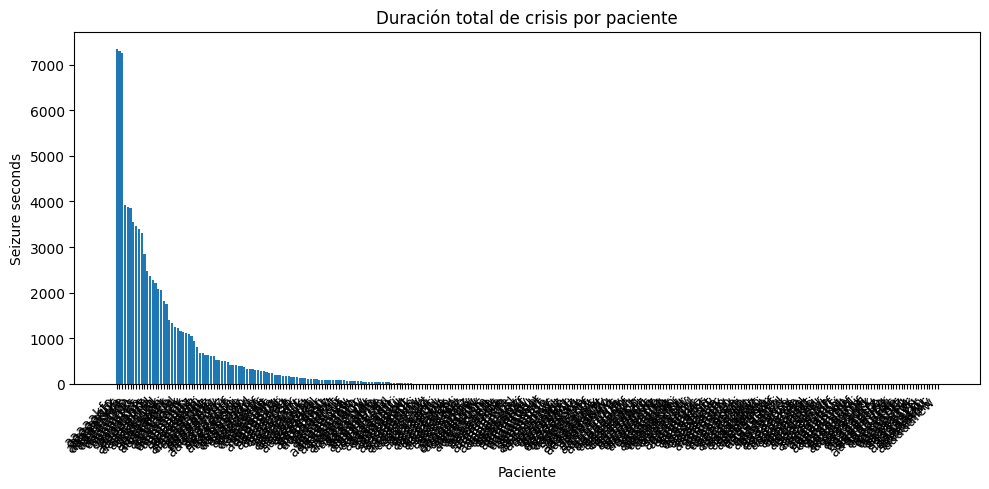

In [64]:
# TYPE: CODE 14.1


import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(outTrainJson)

plt.figure(figsize=(10, 5))

plt.bar(
    df["patient_id"],
    df["seizure_seconds"]
)

plt.xlabel("Paciente")
plt.ylabel("Seizure seconds")
plt.title("Duración total de crisis por paciente")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



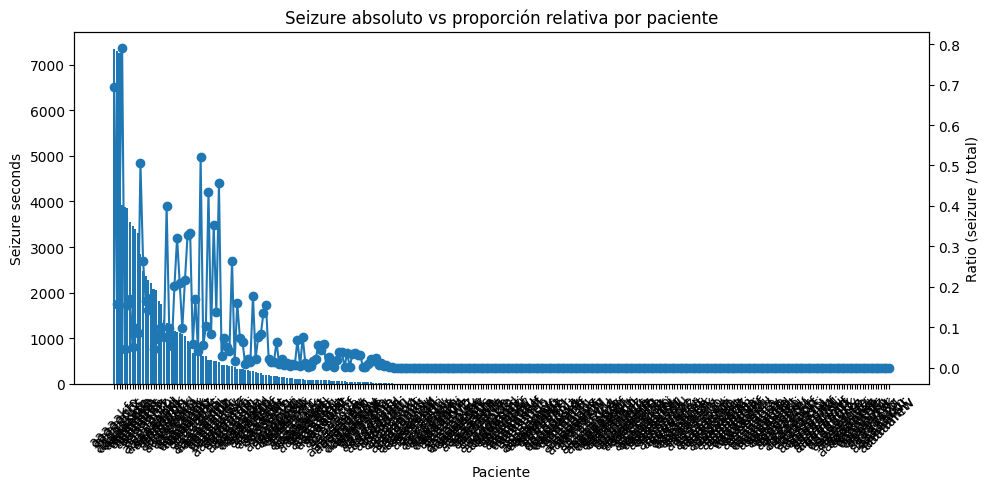

In [65]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# --- EJE Y IZQUIERDO (seizure_seconds) ---
ax1.bar(
    df["patient_id"],
    df["seizure_seconds"],
)
ax1.set_xlabel("Paciente")
ax1.set_ylabel("Seizure seconds")

ax1.tick_params(axis="x", rotation=45)

# --- EJE Y DERECHO (ratio) ---
ax2 = ax1.twinx()
ax2.plot(
    df["patient_id"],
    df["ratio"],
    marker="o"
)
ax2.set_ylabel("Ratio (seizure / total)")

# --- TÍTULO ---
plt.title("Seizure absoluto vs proporción relativa por paciente")

fig.tight_layout()
plt.show()


###### ***BLOCK 15 — TYPE: MARKDOWN***


## ***Selección de pacientes (K_TRAIN/K_VAL/K_TEST)***

Reglas del flujo actual:

- Desde TRAIN (edf/train):
  1) Tomamos un pool de (K_TRAIN + K_VAL) pacientes mejor rankeados por seizure_seconds
  2) Hacemos split reproducible a TRAIN y VAL

- Desde DEV (edf/dev):
  - Tomamos K_TEST pacientes mejor rankeados por seizure_seconds

Esto evita el sesgo de usar los "primeros EDF" y mantiene un criterio claro
para comparar baseline vs adversarial.

También podemos aplicar un filtro mínimo:
- MIN_SEIZURE_SECONDS = 0 (por defecto)
- si luego quieres exigir al menos, digamos, 60s seizure por paciente, lo cambias ahí.


In [91]:
# TYPE: CODE 16
# ===== Parámetros de selección (solo pacientes) =====
# Ajustables según data_mode (pero el concepto NO cambia)
if data_mode == "tiny":
    # K_TRAIN: int = 32
    # K_VAL: int = 8
    # K_TEST: int = 10
    K_TRAIN: int = 1
    K_VAL: int = 1
    K_TEST: int = 1
elif data_mode == "small":
    K_TRAIN = 120
    K_VAL = 30
    K_TEST = 30
elif data_mode == "large":
    K_TRAIN = 250
    K_VAL = 60
    K_TEST = 60
else:  # full
    # En full podrías poner None y tomar todos, pero aquí mantenemos ints para control.
    K_TRAIN = 400
    K_VAL = 100
    K_TEST = 50

MIN_SEIZURE_SECONDS: int = 0
SEED: int = 42

# 1) Pool top (K_TRAIN + K_VAL) desde TRAIN
pool_size: int = K_TRAIN + K_VAL
# train_val_pool_patients: List[str] = select_top_patients_by_seizure_seconds(
train_val_pool_patients: List[str] = select_top_patients_by_some_criteria(
    train_patient_map,
    k=pool_size,
    min_seizure_seconds=MIN_SEIZURE_SECONDS,
)




selected_train_patients: List[str]
selected_val_patients: List[str]
selected_train_patients, selected_val_patients = split_train_val_patients(
    train_val_pool_patients,
    k_train=K_TRAIN,
    k_val=K_VAL,
    seed=SEED,
)

# 2) Top-K desde DEV para test
selected_test_patients: List[str] = select_top_patients_by_some_criteria(
    dev_patient_map,
    k=K_TEST,
    min_seizure_seconds=MIN_SEIZURE_SECONDS,
)

print("=== Pacientes seleccionados ===")
print("Train:", len(selected_train_patients))
print("Val  :", len(selected_val_patients))
print("Test :", len(selected_test_patients))

summarize_patients("TRAIN", selected_train_patients, train_patient_map)
summarize_patients("VAL", selected_val_patients, train_patient_map)
summarize_patients("TEST", selected_test_patients, dev_patient_map)

=== Pacientes seleccionados ===
Train: 1
Val  : 1
Test : 1
TRAIN: n=1 | min=7355s | max=7355s | avg=7355.00s
VAL: n=1 | min=3932s | max=3932s | avg=3932.00s
TEST: n=1 | min=1096s | max=1096s | avg=1096.00s


###### ***BLOCK 17 — TYPE: MARKDOWN***


## ***Construcción de listas de EDF seleccionados***

Ahora convertimos:
- pacientes seleccionados -> EDF paths

Generamos:
- train_paths_selected: EDF de pacientes train
- val_paths_selected: EDF de pacientes val
- test_paths_selected: EDF de pacientes test (desde dev)

Estas listas serán la entrada del pipeline pesado (leer EDF, filtrar, remuestrear, segmentar y guardar).


In [92]:
# TYPE: CODE 18

train_paths_selected: List[str] = filter_paths_by_patients(
    train_val_paths,
    selected_patients=set(selected_train_patients),
    skip_reference_types=SKIP_REFERENCE_TYPES,
)
#Guardamos la informacion de los pacientes  seleccionados para "train"
save_SELECTED_PARTITION(
    train_paths_selected,
    path_json_output=os.path.join(
        RAIZ,
        "preprocesamiento",
        "output",
        "SELECTED_PARTITION_TRAIN_JSON.json",
    ),
    get_labels_complete_fn=get_labels_complete_from_csv_bi_clasificacion_binaria,
)





val_paths_selected: List[str] = filter_paths_by_patients(
    train_val_paths,
    selected_patients=set(selected_val_patients),
    skip_reference_types=SKIP_REFERENCE_TYPES,
)
#Guardamos la informacion de los pacientes  seleccionados para "val"
save_SELECTED_PARTITION(
    val_paths_selected,
    path_json_output=os.path.join(
        RAIZ,
        "preprocesamiento",
        "output",
        "SELECTED_PARTITION_VAL_JSON.json",
    ),
    get_labels_complete_fn=get_labels_complete_from_csv_bi_clasificacion_binaria,
)








test_paths_selected: List[str] = filter_paths_by_patients(
    dev_paths,
    selected_patients=set(selected_test_patients),
    skip_reference_types=SKIP_REFERENCE_TYPES,
)
#Guardamos la informacion de los pacientes  seleccionados para "test"
save_SELECTED_PARTITION(
    test_paths_selected,
    path_json_output=os.path.join(
        RAIZ,
        "preprocesamiento",
        "output",
        "SELECTED_PARTITION_TEST_JSON.json",
    ),
    get_labels_complete_fn=get_labels_complete_from_csv_bi_clasificacion_binaria,
)






# Mezcla reproducible para evitar orden por filesystem
rng = random.Random(SEED)
rng.shuffle(train_paths_selected)
rng.shuffle(val_paths_selected)
rng.shuffle(test_paths_selected)

print("=== EDF seleccionados ===")
print("train_paths_selected:", len(train_paths_selected))
print("val_paths_selected  :", len(val_paths_selected))
print("test_paths_selected :", len(test_paths_selected))

print("\nEjemplos:")
print("train:", train_paths_selected[:2])
print("test :", test_paths_selected[:2])



=== EDF seleccionados ===
train_paths_selected: 19
val_paths_selected  : 6
test_paths_selected : 9

Ejemplos:
train: ['/home/russell/ssd/code/Topicos_Ciencia_Datos/Tesis/dataset/tuh_eeg_seizure/v2.0.3/edf/train/aaaaakfo/s007_2010/01_tcp_ar/aaaaakfo_s007_t000.edf', '/home/russell/ssd/code/Topicos_Ciencia_Datos/Tesis/dataset/tuh_eeg_seizure/v2.0.3/edf/train/aaaaakfo/s007_2010/01_tcp_ar/aaaaakfo_s007_t006.edf']
test : ['/home/russell/ssd/code/Topicos_Ciencia_Datos/Tesis/dataset/tuh_eeg_seizure/v2.0.3/edf/dev/aaaaaajy/s002_2003/01_tcp_ar/aaaaaajy_s002_t002.edf', '/home/russell/ssd/code/Topicos_Ciencia_Datos/Tesis/dataset/tuh_eeg_seizure/v2.0.3/edf/dev/aaaaaajy/s002_2003/01_tcp_ar/aaaaaajy_s002_t001.edf']


###### ***BLOCK 19 — TYPE: MARKDOWN***

## ***Pipeline pesado (EDF -> filtros -> resample -> segmentación -> guardado .npy)***

A partir de aquí ya NO estamos “seleccionando pacientes”, sino procesando señal real.

Entrada:
- train_paths_selected
- val_paths_selected
- test_paths_selected

Salida (nuevo layout acordado):
RAIZ/data_procesada/TUSZ_processed_binary_individual_segments/segment_interval_4_sec/

 ├─ train/{bckg,seizure}/*.npy

 ├─ val/{bckg,seizure}/*.npy

 └─ test/{bckg,seizure}/*.npy

 ___


###### ***BLOCK 20 — TYPE: MARKDOWN***


## ***Notas de Estructuramiento***

El pipeline pesado es largo, así que lo pondremos en un archivo nuevo:

RAIZ/preprocesamiento/src/preprocess_pipeline.py

El notebook solo llamará una función:
`run_preprocessing_for_split(...)`

Esto te permite:
- reusar el mismo pipeline para train/val/test
- mantener el notebook limpio
- testear por separado
___


In [ ]:
# TYPE: CODE 21
from typing import Optional
# Importar el pipeline pesado desde src
from preprocess_pipeline import (
    PreprocessParams,
    run_preprocessing_for_split,
)

# RAIZ/data_procesada/TUSZ_processed_binary_individual_segments/segment_interval_4_sec/
out_base_root: str = os.path.join(
    RAIZ,
    "data_procesada",
    "TUSZ_processed_binary_individual_segments",
    f"segment_interval_{segment_interval}_sec",
)

print("Salida base:", out_base_root)

params = PreprocessParams(
    lowcut=lowcut,
    highcut=highcut,
    fs=fs,
    resampleFS=resampleFS,
    segment_interval=segment_interval,
    seizure_types=seizure_types,
    seizure_overlapping_ratio=seizure_overlapping_ratio,
    skip_reference_types=SKIP_REFERENCE_TYPES,
)

# Para testear rápido (cámbialo a None cuando ya quieras correr full)
MAX_EDFS_TRAIN: Optional[int] = None
MAX_EDFS_VAL: Optional[int] = None
MAX_EDFS_TEST: Optional[int] = 1

print("\n=== RUN: TRAIN ===")
print("No processing TRAIN split in this run.")
# patient_train_stats: Dict[str, Dict[str, float]] = {}
# train_totals = run_preprocessing_for_split(
#     train_paths_selected,
#     split_name="train",
#     out_base=out_base_root,
#     params=params,
#     max_edfs=MAX_EDFS_TRAIN,
#     patient_stats_accumulator=patient_train_stats,
# )

print("\n=== RUN: VAL ===")
print("No processing VAL split in this run.")
# patient_val_stats: Dict[str, Dict[str, float]] = {}
# val_totals = run_preprocessing_for_split(
#     val_paths_selected,
#     split_name="val",
#     out_base=out_base_root,
#     params=params,
#     max_edfs=MAX_EDFS_VAL,
#     patient_stats_accumulator=patient_val_stats,
# )

#modificar MAX_EDFS_TEST a None
print("\n=== RUN: TEST ===")
patient_test_stats: Dict[str, Dict[str, float]] = {}
test_totals = run_preprocessing_for_split(
    test_paths_selected,
    split_name="test",
    out_base=out_base_root,
    params=params,
    max_edfs=MAX_EDFS_TEST,
    patient_stats_accumulator=patient_test_stats,
)

print("\n=== FIN PREPROCESAMIENTO ===")
print("train_totals:", train_totals)
print("val_totals  :", val_totals)
print("test_totals :", test_totals)


Salida base: /home/russell/ssd/code/Topicos_Ciencia_Datos/Tesis/data_procesada/TUSZ_processed_binary_individual_segments/segment_interval_4_sec

=== RUN: TRAIN ===

=== RUN: VAL ===

=== RUN: TEST ===
[process_one_edf] Processing: /home/russell/ssd/code/Topicos_Ciencia_Datos/Tesis/dataset/tuh_eeg_seizure/v2.0.3/edf/dev/aaaaaajy/s002_2003/01_tcp_ar/aaaaaajy_s002_t002.edf
[process_one_edf] Processing: /home/russell/ssd/code/Topicos_Ciencia_Datos/Tesis/dataset/tuh_eeg_seizure/v2.0.3/edf/dev/aaaaaajy/s002_2003/01_tcp_ar/aaaaaajy_s002_t001.edf
[process_one_edf] Processing: /home/russell/ssd/code/Topicos_Ciencia_Datos/Tesis/dataset/tuh_eeg_seizure/v2.0.3/edf/dev/aaaaaajy/s003_2003/01_tcp_ar/aaaaaajy_s003_t000.edf
[process_one_edf] Processing: /home/russell/ssd/code/Topicos_Ciencia_Datos/Tesis/dataset/tuh_eeg_seizure/v2.0.3/edf/dev/aaaaaajy/s003_2003/01_tcp_ar/aaaaaajy_s003_t002.edf
[process_one_edf] Processing: /home/russell/ssd/code/Topicos_Ciencia_Datos/Tesis/dataset/tuh_eeg_seizure/v2.0.3

In [87]:
#Guardamos el ranking de pacientes por split
print("\n=== GUARDANDO RANKING DE PACIENTES POR SPLIT ===")
print("\n--- TRAIN ---")
ranking_train: List[Dict[str, float]] = build_patient_ranking(patient_train_stats)
save_patient_ranking_json(
    ranking_train,
    output_path=os.path.join(
        RAIZ,
        "preprocesamiento",
        "output",
        "patient_train_seizure_ranking.json",
    ),
)

print("\n--- VAL ---")
ranking_val: List[Dict[str, float]] = build_patient_ranking(patient_val_stats)
save_patient_ranking_json(
    ranking_val,
    output_path=os.path.join(
        RAIZ,
        "preprocesamiento",
        "output",
        "patient_val_seizure_ranking.json",
    ),
)

print("\n--- TEST ---")
ranking_test: List[Dict[str, float]] = build_patient_ranking(patient_test_stats)
save_patient_ranking_json(
    ranking_test,
    output_path=os.path.join(
        RAIZ,
        "preprocesamiento",
        "output",
        "patient_test_seizure_ranking.json",
    ),
)



=== GUARDANDO RANKING DE PACIENTES POR SPLIT ===

--- TRAIN ---

--- VAL ---

--- TEST ---


###### ***BLOCK 22 — TYPE: MARKDOWN***


## ***Validación rápida de estructura de salida***

Este bloque solo inspecciona que efectivamente se estén creando:
- train/bckg, train/seizure
- val/bckg, val/seizure
- test/bckg, test/seizure

y muestra cuántos .npy hay en cada carpeta.


In [88]:
# TYPE: CODE 23
from typing import Tuple

def count_npy_files(folder: str) -> int:
    if not os.path.exists(folder):
        return 0
    return sum(1 for f in os.listdir(folder) if f.endswith(".npy"))

splits: List[str] = ["train", "val", "test"]
labs: List[str] = ["bckg", "seizure"]

print("\n=== Conteo de npy por carpeta ===")
for sp in splits:
    for lab in labs:
        folder: str = os.path.join(out_base_root, sp, lab)
        print(f"{sp}/{lab}: {count_npy_files(folder)} archivos .npy")



=== Conteo de npy por carpeta ===
train/bckg: 17 archivos .npy
train/seizure: 18 archivos .npy
val/bckg: 5 archivos .npy
val/seizure: 10 archivos .npy
test/bckg: 11 archivos .npy
test/seizure: 8 archivos .npy
